# ABC Hands — Image Classification with EfficientNetB0

This notebook trains a three-class hand-sign classifier (**A, B and C**) and exports a native Keras model for the hidden test set.

The training recipe is based on the approach that achieved 96% on the hidden test: 224×224 padded images, EfficientNetB0, no horizontal flip, AdamW, two-stage transfer learning, and a final continuation on all labelled images.

> The dataset contains personal images and is not published in this repository.

## 1. Setup

In [1]:
%pip install -q pillow-heif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 54.1 MB/s eta 0:00:00


In [3]:
from pathlib import Path
import json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image, ImageOps
from pillow_heif import register_heif_opener
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from tensorflow import keras
from tensorflow.keras import layers

register_heif_opener()
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 16
CLASS_NAMES = ["A", "B", "C"]
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

Mounted at /content/drive
TensorFlow: 2.20.0
GPU: []


## 2. Paths

Expected private Drive structure:

```text
grouped/
  Participant_01/A/image.jpg
  Participant_01/B/image.jpg
  Participant_01/C/image.jpg
  Participant_02/...
```

In [4]:
DATA_DIR = Path("/content/drive/MyDrive/grouped")
OUTPUT_DIR = Path("/content/drive/MyDrive/ABC_case_study/final_submission")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = OUTPUT_DIR / "abc_hands_efficientnetb0.keras"
METADATA_PATH = OUTPUT_DIR / "model_metadata.json"
assert DATA_DIR.exists(), f"Dataset not found: {DATA_DIR}"
print("Data:", DATA_DIR)
print("Model:", MODEL_PATH)

Data: /content/drive/MyDrive/grouped
Model: /content/drive/MyDrive/ABC_case_study/final_submission/abc_hands_efficientnetb0.keras


## 3. Build and verify the dataset index

In [ ]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".heic", ".heif"}
records = []
for path in sorted(DATA_DIR.rglob("*")):
    if not path.is_file() or path.suffix.lower() not in VALID_EXTENSIONS:
        continue
    relative = path.relative_to(DATA_DIR).parts
    if len(relative) < 3:
        continue
    participant, label = relative[0], path.parent.name.upper()
    if label in CLASS_NAMES:
        records.append({"filepath": str(path), "participant": participant, "label": label})

df = pd.DataFrame(records)
assert not df.empty, "No images found. Expected grouped/participant/class/image."
assert set(df.label.unique()) == set(CLASS_NAMES), "Classes A, B and C are required."
df["target"] = df["label"].map({name:i for i,name in enumerate(CLASS_NAMES)})
print("Images:", len(df))
print("Participants:", df.participant.nunique())
display(pd.crosstab(df.participant, df.label, margins=True))

## 4. Preprocess without distorting the hand

`ImageOps.pad` preserves the aspect ratio. EfficientNetB0 accepts pixels in the 0–255 range, so there is no manual division by 255.

In [6]:
def load_image(path):
    with Image.open(path) as image:
        image = ImageOps.exif_transpose(image).convert("RGB")
        image = ImageOps.pad(
            image, (IMG_SIZE, IMG_SIZE), method=Image.Resampling.BICUBIC,
            color=(0, 0, 0), centering=(0.5, 0.5)
        )
        return np.asarray(image, dtype=np.float32)

print("Loading images...")
X = np.stack([load_image(p) for p in df.filepath])
y = df.target.to_numpy(dtype=np.int64)
print("X:", X.shape, X.dtype, "range:", (X.min(), X.max()))
print("y:", y.shape)
assert X.shape[1:] == (224, 224, 3)

Loading images...
X: (1457, 224, 224, 3) float32 range: (np.float32(0.0), np.float32(255.0))
y: (1457,)


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, idx in zip(axes.flat, np.random.default_rng(SEED).choice(len(X), 8, replace=False)):
    ax.imshow(X[idx].astype("uint8"))
    ax.set_title(f"{df.iloc[idx].label} — {df.iloc[idx].participant}")
    ax.axis("off")
plt.tight_layout()

## 5. One stratified train/validation split

This reproduces the reference workflow; it is **not cross-validation**. The hidden test remains the final external evaluation.

In [8]:
train_idx, val_idx = train_test_split(
    np.arange(len(X)), test_size=0.20, stratify=y, random_state=SEED
)
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
print("Train:", X_train.shape, np.bincount(y_train))
print("Validation:", X_val.shape, np.bincount(y_val))

Train: (1165, 224, 224, 3) [392 381 392]
Validation: (292, 224, 224, 3) [98 96 98]


## 6. EfficientNetB0 model

In [9]:
def build_model():
    base = keras.applications.EfficientNetB0(
        include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False
    inputs = keras.Input((IMG_SIZE, IMG_SIZE, 3), name="image")
    x = layers.RandomRotation(0.08)(inputs)
    x = layers.RandomZoom(0.10)(x)
    x = layers.RandomBrightness(0.15)(x)
    x = layers.RandomContrast(0.15)(x)
    # No horizontal flip: mirrored hand signs can be unrealistic.
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.50)(x)
    outputs = layers.Dense(3, activation="softmax", name="class_probabilities")(x)
    return keras.Model(inputs, outputs, name="ABC_Hands_EfficientNetB0"), base

model, base = build_model()
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ABC_Hands_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 224, 224, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        40,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,090,662 (15.60 MB)

 Trainable params: 41,091 (160.51 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 7. Phase 1 — frozen backbone

In [10]:
def callbacks():
    return [keras.callbacks.EarlyStopping(
        monitor="val_accuracy", mode="max", patience=5,
        restore_best_weights=True, verbose=1
    )]

model.compile(
    optimizer=keras.optimizers.AdamW(1e-3, weight_decay=1e-4),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
history_frozen = model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=20, batch_size=BATCH_SIZE, callbacks=callbacks(), verbose=1
)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.6034 - loss: 0.8441 - val_accuracy: 0.9178 - val_loss: 0.5085
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.8034 - loss: 0.5134 - val_accuracy: 0.9075 - val_loss: 0.3040
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.8541 - loss: 0.3844 - val_accuracy: 0.9555 - val_loss: 0.2209
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.8944 - loss: 0.3011 - val_accuracy: 0.9623 - val_loss: 0.1777
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.9082 - loss: 0.2623 - val_accuracy: 0.9555 - val_loss: 0.1683
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.9219 - loss: 0.2434 - val_accuracy: 0.9623 - val_loss: 0.1447
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9322 - loss: 0.2195 - val_accuracy: 0.9521 - val_loss: 0.1410
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9288 - loss: 0.1944 - val_accuracy: 0.9555 - val_

## 8. Phase 2 — fine-tune the last 60 layers

In [11]:
base.trainable = True
for layer in base.layers[:-60]:
    layer.trainable = False
for layer in base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.AdamW(1e-5, weight_decay=1e-4),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
history_finetune = model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=20, batch_size=BATCH_SIZE, callbacks=callbacks(), verbose=1
)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.9554 - loss: 0.1214 - val_accuracy: 0.9692 - val_loss: 0.1090
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.9725 - loss: 0.0954 - val_accuracy: 0.9692 - val_loss: 0.1045
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.9682 - loss: 0.0983 - val_accuracy: 0.9692 - val_loss: 0.0903
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.9777 - loss: 0.0794 - val_accuracy: 0.9692 - val_loss: 0.0853
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.9811 - loss: 0.0693 - val_accuracy: 0.9726 - val_loss: 0.0883
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.9794 - loss: 0.0671 - val_accuracy: 0.9726 - val_loss: 0.0852
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.9888 - loss: 0.0480 - val_accuracy: 0.9726 - val_loss: 0.0844
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.9871 - loss: 0.0463 - val_accuracy: 0.9726 - v

## 9. Validation results

              precision    recall  f1-score   support

           A     0.9417    0.9898    0.9652        98
           B     0.9783    0.9375    0.9574        96
           C     1.0000    0.9898    0.9949        98

    accuracy                         0.9726       292
   macro avg     0.9733    0.9724    0.9725       292
weighted avg     0.9733    0.9726    0.9726       292



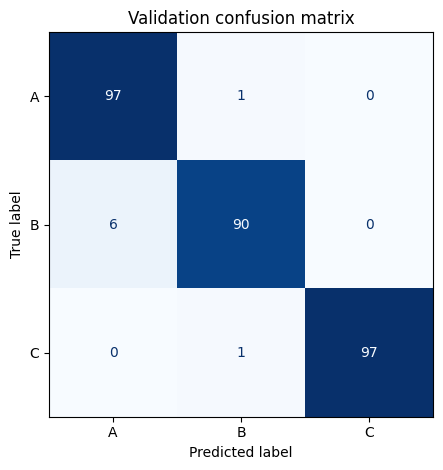

In [12]:
val_prob = model.predict(X_val, batch_size=BATCH_SIZE, verbose=0)
val_pred = val_prob.argmax(axis=1)
print(classification_report(y_val, val_pred, target_names=CLASS_NAMES, digits=4))
cm = confusion_matrix(y_val, val_pred, labels=range(3))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(cmap="Blues", colorbar=False)
plt.title("Validation confusion matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "validation_confusion_matrix.png", dpi=180)
plt.show()

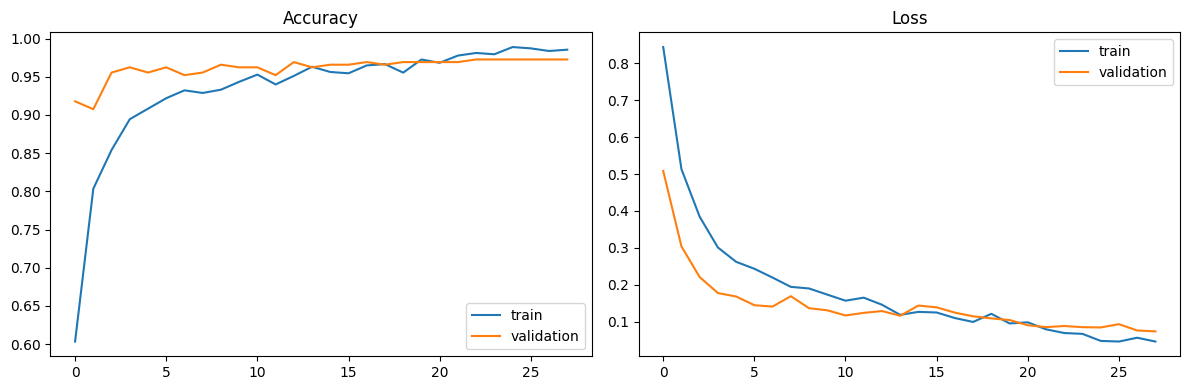

In [13]:
def plot_history(histories):
    acc, val_acc, loss, val_loss = [], [], [], []
    for h in histories:
        acc += h.history["accuracy"]; val_acc += h.history["val_accuracy"]
        loss += h.history["loss"]; val_loss += h.history["val_loss"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(acc, label="train"); axes[0].plot(val_acc, label="validation")
    axes[0].set_title("Accuracy"); axes[0].legend()
    axes[1].plot(loss, label="train"); axes[1].plot(val_loss, label="validation")
    axes[1].set_title("Loss"); axes[1].legend()
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=180); plt.show()
plot_history([history_frozen, history_finetune])

## 10. Continue on all labelled images and export

The validated model is continued for 10 short epochs on all available labelled images, matching the reference submission recipe. These training accuracies are not evaluation scores.

In [14]:
FINAL_EPOCHS = 10
model.compile(
    optimizer=keras.optimizers.AdamW(1e-5, weight_decay=1e-4),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
history_all = model.fit(
    X, y, epochs=FINAL_EPOCHS, batch_size=BATCH_SIZE, shuffle=True, verbose=1
)
model.save(MODEL_PATH)

metadata = {
    "classes": CLASS_NAMES,
    "image_size": [IMG_SIZE, IMG_SIZE],
    "preprocessing": "EXIF transpose, RGB, aspect-ratio preserving pad, pixels 0-255",
    "architecture": "EfficientNetB0 + Dense(32) + Dropout(0.5)",
    "images": int(len(df)),
    "participants": int(df.participant.nunique()),
    "final_epochs_all_data": FINAL_EPOCHS,
}
METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
print("Saved:", MODEL_PATH)
print("Size MB:", MODEL_PATH.stat().st_size / 1024**2)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9794 - loss: 0.0647
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.9794 - loss: 0.0644
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.9767 - loss: 0.0604
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.9828 - loss: 0.0516
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9828 - loss: 0.0538
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9870 - loss: 0.0392
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9904 - loss: 0.0387
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9842 - loss: 0.0429
Epoch 9/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9828 - loss: 0.0490
Epoch 10/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9876 - loss: 0.0370
Saved: /content/drive/MyDrive/ABC_case_study/final_submission/abc_hands_efficientnetb0.keras
Size MB: 36.971641540527344


## 11. Reload and verify the deliverable

In [15]:
reloaded = keras.models.load_model(MODEL_PATH, compile=False)
assert reloaded.input_shape == (None, 224, 224, 3)
assert reloaded.output_shape == (None, 3)
probe = reloaded.predict(X[:2], verbose=0)
assert np.allclose(probe.sum(axis=1), 1.0, atol=1e-5)
print("Model verified:", MODEL_PATH)
print("Input:", reloaded.input_shape, "Output:", reloaded.output_shape)

Model verified: /content/drive/MyDrive/ABC_case_study/final_submission/abc_hands_efficientnetb0.keras
Input: (None, 224, 224, 3) Output: (None, 3)


## Final results

| Evaluation | Accuracy | Macro F1 |
|---|---:|---:|
| Stratified validation split (292 images) | **97.26%** | **97.25%** |
| Hidden external test | **94.95%** | Not provided |

The validation result is based on one image-level stratified split, **not cross-validation**. The hidden external test provides the strongest evidence of generalization. Participant images and participant-level outputs are deliberately removed from this public notebook.
